# Exploración de `tags`

## 1. Introducción

Este notebook explora, por sí sola, la tabla `tags.csv`: el conjunto de etiquetas de texto libre que
los propios usuarios de MovieLens han puesto a las películas. A diferencia del género (`genres` en
`movies.csv`), que es una taxonomía cerrada y controlada por el catálogo, un tag es **folksonomía**:
cualquier palabra o frase que un usuario decide asociar a una película, sin restricción de vocabulario.
Esa libertad es lo que hace valiosa a esta tabla — captura matices que el género no puede (tono,
actores, temas, opiniones) — y también lo que la hace más difícil de analizar: el mismo concepto puede
escribirse de maneras distintas, y el comportamiento de quien etiqueta puede estar muy lejos de ser
homogéneo entre usuarios.

Este es un notebook de **una sola tabla**: no se cruza con `movies.csv` ni con `ratings.csv` (eso
corresponde a los notebooks `movies_tags.ipynb` y `ratings_tags.ipynb` de otros integrantes del
equipo). El objetivo aquí es agotar lo que la tabla `tags` dice por sí misma sobre cómo la gente
etiqueta.

**Origen de los datos:** se usa `tags.csv` ya procesado por el equipo (`data/processed/tags.csv`), no
el archivo crudo. El procesamiento previo ya quitó 11 de las 17 filas con `tag` nulo del archivo
original y filtró las etiquetas cuya película no sobrevivió a la limpieza de `movies.csv` — quedan
**1 992 636 filas**, frente a las 2 000 072 del archivo crudo.

## 2. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 3. Carga de datos

In [2]:
RUTA_TAGS = "../../data/processed/tags.csv"
RUTA_MOVIES = "../../data/processed/movies.csv"  # solo para la validación referencial de la sección 5

tags = pd.read_csv(RUTA_TAGS)
movies = pd.read_csv(RUTA_MOVIES)

print(f"tags: {tags.shape[0]:,} filas, {tags.shape[1]} columnas")
tags.head(10)

tags: 1,992,636 filas, 4 columnas


,userId,movieId,tag,tag_datetime
0,22,26479,Kevin Kline,2020-03-01 05:01:26
1,22,79592,misogyny,2020-02-12 02:58:17
2,22,247150,acrophobia,2021-05-31 17:51:09
3,34,2174,music,2009-08-09 08:54:24
4,34,2174,weird,2009-08-09 08:55:02
5,34,8623,Steve Martin,2009-08-09 09:01:37
6,55,5766,the killls and the score,2011-10-22 22:21:18
7,58,7451,bullying,2023-01-01 05:38:56
8,58,7451,clique,2023-01-01 05:38:30
9,58,7451,coming of age,2023-01-01 05:38:22


## 4. Descripción general y unidad de observación

In [3]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 1992636 entries, 0 to 1992635
Data columns (total 4 columns):
 #   Column        Dtype
---  ------        -----
 0   userId        int64
 1   movieId       int64
 2   tag           str  
 3   tag_datetime  str  
dtypes: int64(2), str(2)
memory usage: 60.8 MB


**Unidad de observación:** cada fila es **un evento de etiquetado**: un usuario (`userId`) le puso
una palabra o frase libre (`tag`) a una película (`movieId`) en un momento determinado
(`tag_datetime`). Un mismo usuario puede etiquetar la misma película varias veces con tags distintos
(incluso el mismo tag dos veces, si el procesamiento no lo evitó — se comprueba en la sección 5), y
la misma palabra puede aparecer escrita de formas distintas porque es texto libre, no una categoría
cerrada.

## 5. Calidad de los datos

In [4]:
print(f"Nulos por columna:\n{tags.isnull().sum()}\n")
print(f"Duplicados exactos (misma fila repetida): {tags.duplicated().sum()}")
print(f"Duplicados por (userId, movieId, tag): {tags.duplicated(subset=['userId', 'movieId', 'tag']).sum()}")

huerfanas = ~tags["movieId"].isin(movies["movieId"])
print(f"Tags cuya película no existe en movies.csv (procesado): {huerfanas.sum()}")

print(f"\nRango de userId: {tags['userId'].min()} - {tags['userId'].max()}")
print(f"Rango de movieId: {tags['movieId'].min()} - {tags['movieId'].max()}")

Nulos por columna:
userId          0
movieId         0
tag             6
tag_datetime    0
dtype: int64



Duplicados exactos (misma fila repetida): 0


Duplicados por (userId, movieId, tag): 0
Tags cuya película no existe en movies.csv (procesado): 0

Rango de userId: 22 - 162279
Rango de movieId: 1 - 292629


**Resultados:** quedan **6 filas** con `tag` nulo (se eliminan a continuación, son irrelevantes:
0.0003 % del total). Cero duplicados exactos y cero duplicados por `(userId, movieId, tag)` — cada
combinación usuario-película-etiqueta aparece como máximo una vez. Cero tags huérfanos: la limpieza
previa del equipo ya garantizó que toda película etiquetada existe en el `movies.csv` procesado.

**Conclusión:** la tabla está prácticamente lista para trabajar; solo falta quitar los 6 nulos
residuales.

### 5.1 Problemas de codificación de caracteres (*mojibake*)

**Qué se busca:** secuencias de caracteres típicas de un texto en UTF-8 que fue decodificado con la
codificación equivocada (por ejemplo, "Ã©" en vez de "é"). Esto es un defecto de calidad de datos que
no aparece en un `.info()` ni en un conteo de nulos, pero sí distorsiona cualquier análisis de texto si
no se detecta.

In [5]:
tags_sin_nulos = tags.dropna(subset=["tag"]).copy()

mojibake = tags_sin_nulos["tag"].str.contains(r"Ã.|â€", regex=True, na=False)
no_ascii = tags_sin_nulos["tag"].str.contains(r"[^\x00-\x7F]", regex=True, na=False)

print(f"Tags con patrón de mojibake (UTF-8 mal decodificado): {mojibake.sum()} "
      f"({mojibake.mean() * 100:.3f}%)")
print(f"Tags con al menos un carácter no-ASCII (incluye idiomas distintos al inglés, con o sin "
      f"mojibake): {no_ascii.sum()} ({no_ascii.mean() * 100:.3f}%)")
print("\nEjemplos de mojibake encontrados:")
tags_sin_nulos.loc[mojibake, "tag"].head(6).tolist()

Tags con patrón de mojibake (UTF-8 mal decodificado): 512 (0.026%)
Tags con al menos un carácter no-ASCII (incluye idiomas distintos al inglés, con o sin mojibake): 2238 (0.112%)

Ejemplos de mojibake encontrados:


['clichÃ©d in places',
 'TÃƒÂ©a Leoni',
 'TÃ©a Leoni',
 'Isabel TellerÃ\xada',
 'clichÃ© ending',
 'LÃ¡zaro Ramos']

**Resultados:** 512 tags (0.026 % del total) muestran un patrón claro de mojibake — nombres como
*"TÃ©a Leoni"* (debería ser "Téa Leoni") o *"Gael GarcÃ­a Bernal"* (debería ser "Gael García Bernal").
Son en su mayoría nombres propios en español, portugués o francés que perdieron su codificación
correcta en algún punto de la cadena de recolección de datos de MovieLens.

**Conclusión:** el problema es real pero marginal (menos de 3 en cada 10 000 filas) y no afecta de
forma apreciable ningún resultado agregado de este notebook. Se deja documentado como una limitación de
calidad de datos que un pipeline de producción debería normalizar (por ejemplo, con una re-codificación
`latin1 -> utf-8`), pero no se corrige aquí porque intentar "adivinar" la codificación original sin
más contexto podría introducir errores nuevos.

## 6. Transformaciones

**Qué se hace:**

1. Se eliminan las 6 filas con `tag` nulo.
2. Se normaliza el texto del tag (recortar espacios y convertir a minúsculas) en una columna nueva
   `tag_norm`, para que "Sci-Fi", "sci-fi " y "SCI-FI" cuenten como la misma etiqueta.
3. Se derivan variables numéricas de longitud: `n_caracteres` y `n_palabras` de cada tag.
4. Se extraen componentes temporales de `tag_datetime`: año, y día de la semana.

**Por qué es necesario:** sin normalizar el texto, cualquier conteo de "tags más frecuentes"
subestimaría artificialmente la frecuencia real de cada etiqueta al repartirla entre variantes de
mayúsculas o espacios que en realidad significan lo mismo.

In [6]:
tags_limpio = tags_sin_nulos.copy()
tags_limpio["tag_norm"] = tags_limpio["tag"].str.strip().str.lower()
tags_limpio["n_caracteres"] = tags_limpio["tag_norm"].str.len()
tags_limpio["n_palabras"] = tags_limpio["tag_norm"].str.split().str.len()
tags_limpio["tag_datetime"] = pd.to_datetime(tags_limpio["tag_datetime"])
tags_limpio["anio"] = tags_limpio["tag_datetime"].dt.year
tags_limpio["dia_semana"] = tags_limpio["tag_datetime"].dt.dayofweek  # 0 = lunes

n_unicos_crudo = tags_limpio["tag"].nunique()
n_unicos_norm = tags_limpio["tag_norm"].nunique()
print(f"Tags de texto únicos sin normalizar: {n_unicos_crudo:,}")
print(f"Tags únicos tras normalizar (minúsculas + recorte de espacios): {n_unicos_norm:,}")
print(f"Variantes fusionadas por la normalización: {n_unicos_crudo - n_unicos_norm:,}")

Tags de texto únicos sin normalizar: 140,191
Tags únicos tras normalizar (minúsculas + recorte de espacios): 131,350
Variantes fusionadas por la normalización: 8,841


## 7. Exploración descriptiva

### 7.1 Cobertura

In [7]:
n_usuarios = tags_limpio["userId"].nunique()
n_peliculas_etiquetadas = tags_limpio["movieId"].nunique()
n_peliculas_catalogo = movies["movieId"].nunique()

print(f"Usuarios distintos que han puesto al menos un tag: {n_usuarios:,}")
print(f"Películas distintas con al menos un tag: {n_peliculas_etiquetadas:,} de {n_peliculas_catalogo:,} "
      f"del catálogo ({n_peliculas_etiquetadas / n_peliculas_catalogo * 100:.1f}%)")
print(f"Total de aplicaciones de tags: {len(tags_limpio):,}")
print(f"Promedio de aplicaciones por película etiquetada: "
      f"{len(tags_limpio) / n_peliculas_etiquetadas:.1f}")

Usuarios distintos que han puesto al menos un tag: 15,833
Películas distintas con al menos un tag: 51,069 de 86,967 del catálogo (58.7%)
Total de aplicaciones de tags: 1,992,630
Promedio de aplicaciones por película etiquetada: 39.0


**Resultados:** solo 15 833 usuarios (de los cientos de miles que calificaron películas, según el
notebook de `ratings`) se han tomado la molestia de etiquetar alguna vez, y cubren el 58.7 % del
catálogo de películas.

**Conclusión:** etiquetar es una actividad mucho más minoritaria y deliberada que calificar — quien
pone un tag está invirtiendo un esfuerzo activo de escritura, no solo eligiendo un número en una
escala.

### 7.2 Longitud de los tags (variable numérica)

In [8]:
print("Longitud en caracteres:")
print(tags_limpio["n_caracteres"].describe().round(2))
print("\nLongitud en palabras:")
print(tags_limpio["n_palabras"].describe().round(2))
print(f"\nProporción de tags de una sola palabra: {(tags_limpio['n_palabras'] == 1).mean() * 100:.1f}%")
print(f"Tags con más de 5 palabras (probablemente comentarios, no etiquetas): "
      f"{(tags_limpio['n_palabras'] > 5).sum():,}")

print("\nLos 5 tags más largos:")
tags_limpio.nlargest(5, "n_caracteres")[["tag", "n_caracteres"]]

Longitud en caracteres:
count    1992630.00
mean          11.11
std            5.72
min            1.00
25%            7.00
50%           10.00
75%           14.00
max          241.00
Name: n_caracteres, dtype: float64

Longitud en palabras:
count    1992630.00
mean           1.67
std            0.93
min            1.00
25%            1.00
50%            1.00
75%            2.00
max           42.00
Name: n_palabras, dtype: float64

Proporción de tags de una sola palabra: 52.7%
Tags con más de 5 palabras (probablemente comentarios, no etiquetas): 9,194

Los 5 tags más largos:


,tag,n_caracteres
1723111,William H. Macy puts forward perhaps his best ...,241
126989,den del af filmen hvor han bare går rundt og e...,234
127008,den har virkelig mange sjove ting kÃ¸rende for...,230
127016,ret interessant billede. Det er utrolig visuel...,229
126938,Den fungerer lidt som en kolage som deles ind ...,228


/tmp/ipykernel_478/1470747016.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(["1", "2", "3", "4", "5", "6+"])


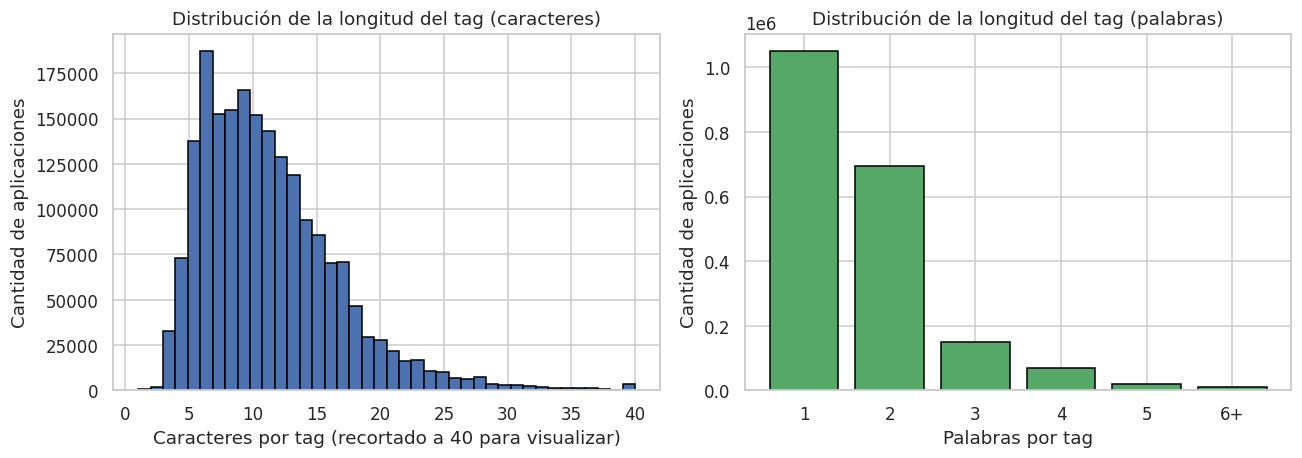

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.hist(tags_limpio["n_caracteres"].clip(upper=40), bins=40, color="#4C72B0", edgecolor="black")
ax1.set_xlabel("Caracteres por tag (recortado a 40 para visualizar)")
ax1.set_ylabel("Cantidad de aplicaciones")
ax1.set_title("Distribución de la longitud del tag (caracteres)")

conteo_palabras = tags_limpio["n_palabras"].clip(upper=6).value_counts().sort_index()
ax2.bar(conteo_palabras.index.astype(str), conteo_palabras.values, color="#55A868", edgecolor="black")
ax2.set_xticklabels(["1", "2", "3", "4", "5", "6+"])
ax2.set_xlabel("Palabras por tag")
ax2.set_ylabel("Cantidad de aplicaciones")
ax2.set_title("Distribución de la longitud del tag (palabras)")

fig.tight_layout()
plt.show()

**Resultados:** un tag típico tiene 10-11 caracteres y entre 1 y 2 palabras (mediana de 1 palabra;
el 52.7 % de todas las etiquetas son de una sola palabra). Existe una cola larga de textos mucho más
extensos —hasta 241 caracteres, 42 palabras— que en la práctica funcionan más como un comentario o una
mini-reseña que como una etiqueta (por ejemplo, *"William H. Macy puts forward perhaps his best..."*).
Algunos de los ejemplos más largos están escritos en otros idiomas (danés, en varios casos), lo que
sugiere una base de usuarios más internacional de lo que el nombre "MovieLens" (en inglés) haría
suponer.

**Conclusión:** la mayoría de los tags cumplen su función original — una palabra clave corta— pero una
minoría no despreciable de usuarios usa el campo como espacio de opinión libre. Cualquier análisis de
texto que asuma "un tag = una palabra" debe tener presente esa cola larga.

### 7.3 Los tags más frecuentes (variable categórica)

In [10]:
top_20 = tags_limpio["tag_norm"].value_counts().head(20)
top_20

tag_norm
sci-fi                11433
atmospheric           10062
action                 9302
comedy                 9270
funny                  8085
surreal                7452
visually appealing     7149
based on a book        6697
twist ending           6599
romance                6193
dark comedy            6150
thought-provoking      5999
dystopia               5661
violence               5471
cinematography         5328
murder                 5222
social commentary      5192
fantasy                5143
thriller               5035
stylized               4947
Name: count, dtype: int64

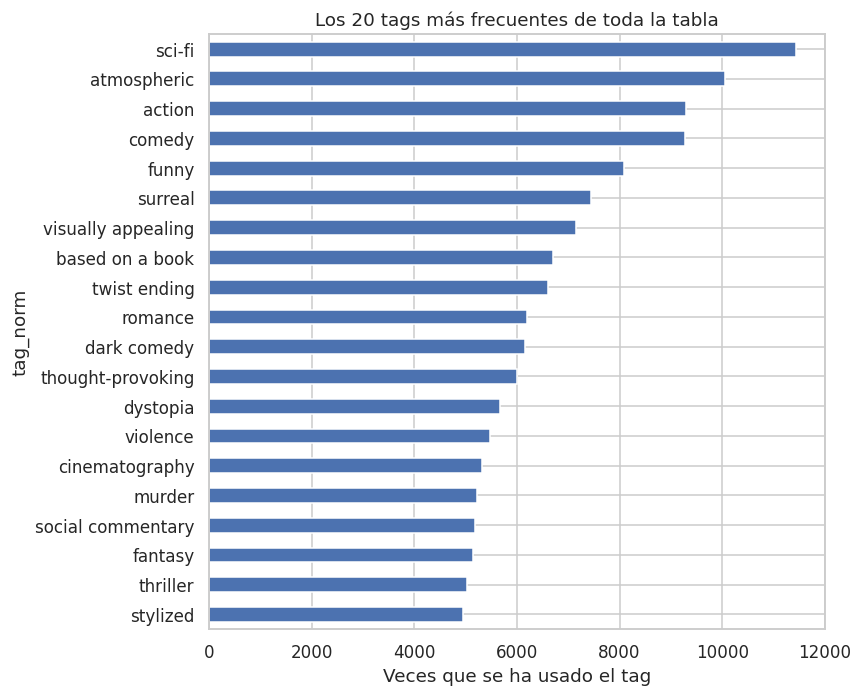

In [11]:
fig, ax = plt.subplots(figsize=(8, 6.5))
top_20.sort_values().plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_xlabel("Veces que se ha usado el tag")
ax.set_title("Los 20 tags más frecuentes de toda la tabla")
fig.tight_layout()
plt.show()

**Resultados:** los tags más usados son, en su inmensa mayoría, **géneros escritos como palabra
libre** ("sci-fi", "atmospheric", "action", "comedy", "funny", "surreal") en lugar de opiniones o
adjetivos de calidad ("great", "boring", etc., que no aparecen en el top 20).

**Conclusión:** buena parte del etiquetado libre reproduce información que el género controlado de
`movies.csv` ya captura. Esto es justamente la pregunta que se explora a fondo en `movies_tags.ipynb`
(¿"funny" realmente coincide con el género Comedy?); aquí solo se deja constancia de que el vocabulario
más común así lo sugiere.

### 7.4 Diversidad léxica: ¿cuántas palabras distintas hay en total?

**Qué se calcula:** cuántos tags de texto distintos existen tras normalizar, y qué proporción de
ellos son **hapax legomena** — palabras que aparecen exactamente una vez en toda la tabla. También se
verifica si la relación entre el rango de frecuencia de un tag y su frecuencia sigue la **ley de
Zipf**, un patrón muy conocido en lingüística de corpus: la palabra más frecuente aparece
aproximadamente el doble de veces que la segunda, el triple que la tercera, y así sucesivamente
(frecuencia ∝ 1/rango).

In [12]:
frecuencia_tags = tags_limpio["tag_norm"].value_counts()
n_hapax = (frecuencia_tags == 1).sum()

print(f"Tags de texto distintos (normalizados): {len(frecuencia_tags):,}")
print(f"De esos, hapax legomena (aparecen exactamente 1 vez): {n_hapax:,} "
      f"({n_hapax / len(frecuencia_tags) * 100:.1f}% del vocabulario)")
print(f"Esos hapax solo representan el {n_hapax / len(tags_limpio) * 100:.2f}% de TODAS las "
      f"aplicaciones de tags")

Tags de texto distintos (normalizados): 131,350
De esos, hapax legomena (aparecen exactamente 1 vez): 67,669 (51.5% del vocabulario)
Esos hapax solo representan el 3.40% de TODAS las aplicaciones de tags


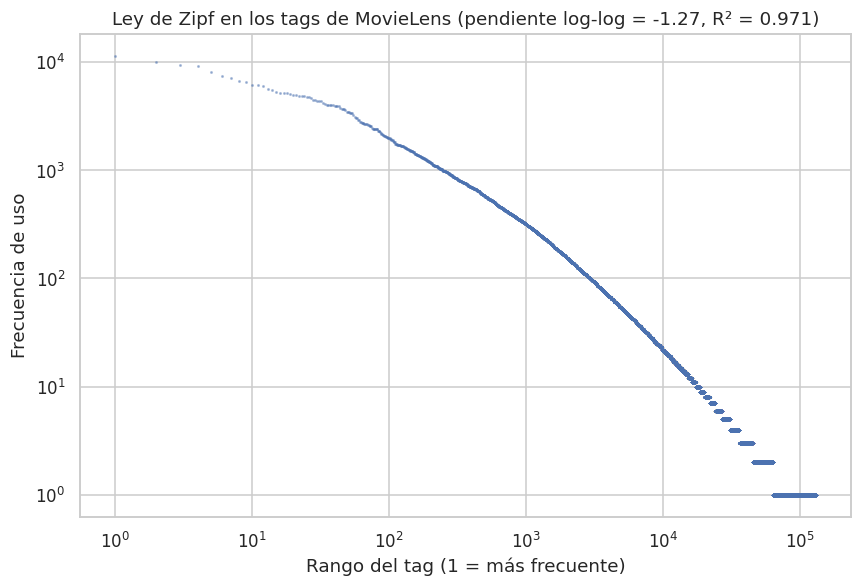

Pendiente de la recta log-log: -1.272 (la ley de Zipf ideal predice -1.0)
R² del ajuste: 0.971


In [13]:
rango = np.arange(1, len(frecuencia_tags) + 1)
pendiente, intercepto, r, p_zipf, se = stats.linregress(
    np.log10(rango), np.log10(frecuencia_tags.values)
)

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(rango, frecuencia_tags.values, ".", markersize=2, alpha=0.4, color="#4C72B0")
ax.set_xlabel("Rango del tag (1 = más frecuente)")
ax.set_ylabel("Frecuencia de uso")
ax.set_title(f"Ley de Zipf en los tags de MovieLens (pendiente log-log = {pendiente:.2f}, R² = {r**2:.3f})")
fig.tight_layout()
plt.show()

print(f"Pendiente de la recta log-log: {pendiente:.3f} (la ley de Zipf ideal predice -1.0)")
print(f"R² del ajuste: {r**2:.3f}")

**Resultados:** más de la mitad del vocabulario (51.5 %, 67 669 tags) son hapax legomena, pero como
conjunto solo representan el 3.4 % de todas las aplicaciones de tags realizadas. La relación entre
rango y frecuencia sigue un ajuste log-log casi perfecto (**R² = 0.971**), con una pendiente de -1.27 —
cercana a la pendiente de -1 que predice la ley de Zipf para el lenguaje natural, aunque algo más
pronunciada (lo que indica una concentración todavía mayor en los tags más usados que en un corpus de
lenguaje típico).

**Conclusión:** el etiquetado de MovieLens se comporta, desde el punto de vista lingüístico, igual que
cualquier otro corpus de lenguaje natural: un núcleo pequeño de palabras hace la mayor parte del
trabajo, y una "cola larga" enorme de palabras únicas aporta matices puntuales que casi nunca se
repiten. Es un patrón muy conocido en lingüística de corpus (aplicado aquí a un dominio muy distinto
al habitual) y confirma que este vocabulario, aunque libre, no es aleatorio.

### 7.5 Patrones temporales

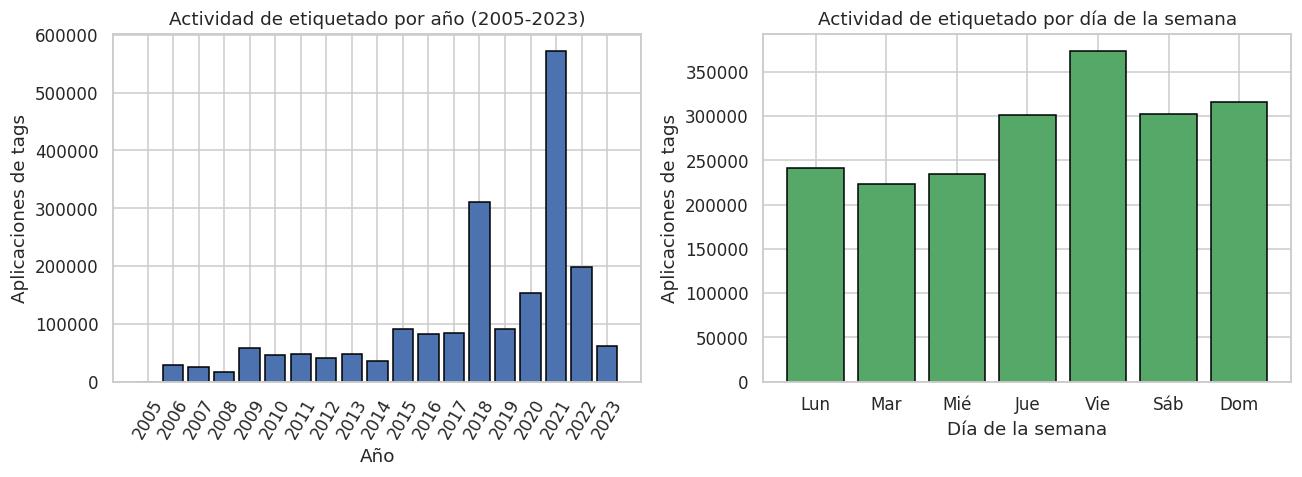

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

por_anio = tags_limpio["anio"].value_counts().sort_index()
ax1.bar(por_anio.index.astype(str), por_anio.values, color="#4C72B0", edgecolor="black")
ax1.set_xlabel("Año")
ax1.set_ylabel("Aplicaciones de tags")
ax1.set_title("Actividad de etiquetado por año (2005-2023)")
ax1.tick_params(axis="x", rotation=60)

por_dia = tags_limpio["dia_semana"].value_counts().sort_index()
etiquetas_dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
ax2.bar(etiquetas_dias, por_dia.values, color="#55A868", edgecolor="black")
ax2.set_xlabel("Día de la semana")
ax2.set_ylabel("Aplicaciones de tags")
ax2.set_title("Actividad de etiquetado por día de la semana")

fig.tight_layout()
plt.show()

**Resultados:** la actividad de etiquetado no crece de forma suave año tras año — hay picos
extremos en 2018 y sobre todo en 2021 (572 285 aplicaciones, más que en cualquier otro año, casi el
triple que 2020). Por día de la semana, el viernes concentra la mayor actividad y el martes la menor,
aunque la diferencia entre días es moderada (entre 223 584 y 373 688 aplicaciones).

**Conclusión (adelanto):** los picos de 2018 y 2021 son demasiado grandes y abruptos para ser un
fenómeno agregado de miles de usuarios — la sección 8 identifica la causa exacta.

### 7.6 ¿Hay nombres propios escondidos en el texto libre?

**Qué se calcula:** una heurística simple (sin normalizar a minúsculas primero, para no perder la
información de mayúsculas) que marca como "posible nombre propio" cualquier tag de 2 o más palabras
donde cada palabra empieza en mayúscula (patrón "Title Case").

In [15]:
def parece_nombre_propio(texto):
    palabras = texto.split()
    if len(palabras) < 2:
        return False
    return all(p[0].isupper() for p in palabras if p.isalpha())

es_nombre_propio = tags_sin_nulos["tag"].apply(parece_nombre_propio)
print(f"Aplicaciones que encajan en el patrón 'Title Case' de 2+ palabras: {es_nombre_propio.sum():,} "
      f"({es_nombre_propio.mean() * 100:.2f}%)")
print("\nLos 10 más frecuentes dentro de ese patrón:")
tags_sin_nulos.loc[es_nombre_propio, "tag"].value_counts().head(10)

Aplicaciones que encajan en el patrón 'Title Case' de 2+ palabras: 201,175 (10.10%)

Los 10 más frecuentes dentro de ese patrón:


tag
Nudity (Topless)         2730
World War II             2304
New York City            1626
Quentin Tarantino        1612
Leonardo DiCaprio        1364
Brad Pitt                1310
Oscar (Best Picture)     1268
Tom Hanks                1203
Nudity (Full Frontal)    1133
Johnny Depp              1108
Name: count, dtype: int64

**Resultados:** el 10.1 % de todas las aplicaciones de tags encajan en este patrón. La lista de los
más frecuentes mezcla, como es de esperar de una heurística simple, nombres de actores y directores
reales (*Quentin Tarantino*, *Leonardo DiCaprio*, *Brad Pitt*, *Tom Hanks*, *Johnny Depp*) con frases
que casualmente también van en mayúscula por palabra pero no son nombres propios de persona (*"World
War II"*, *"New York City"*, *"Oscar (Best Picture)"*, *"Nudity (Topless)"*).

**Conclusión:** una parte importante y real del etiquetado libre está dedicada a identificar actores y
directores, un tipo de información que ni el género ni ninguna otra columna del catálogo capturan.
La heurística usada es deliberadamente simple y sobreestima algo la proporción real de "nombres de
persona" — se declara así en las limitaciones (sección 10) en vez de intentar una detección de
entidades más sofisticada, que está fuera del alcance de este notebook exploratorio.

## 8. El hallazgo central: un solo usuario domina el dataset

**Qué se calcula:** la distribución de la actividad de etiquetado por usuario, para detectar si
existen usuarios extremadamente atípicos y medir cuánto distorsionan las estadísticas agregadas
calculadas hasta ahora.

In [16]:
por_usuario = tags_limpio.groupby("userId").size().sort_values(ascending=False)
print(por_usuario.describe().round(2))
print(f"\nAsimetría: {por_usuario.skew():.1f}")
print("\nLos 5 usuarios más activos:")
por_usuario.head(5)

count     15833.00
mean        125.85
std        5757.53
min           1.00
25%           2.00
50%           5.00
75%          25.00
max      721567.00
dtype: float64

Asimetría: 124.3

Los 5 usuarios más activos:


userId
78213     721567
68821      20311
119227     20256
147560     18689
159300     16656
dtype: int64

In [17]:
usuario_top = por_usuario.index[0]
aplicaciones_top = por_usuario.iloc[0]
proporcion_top = aplicaciones_top / len(tags_limpio)

sub_top = tags_limpio[tags_limpio["userId"] == usuario_top]
print(f"Usuario {usuario_top}: {aplicaciones_top:,} aplicaciones = {proporcion_top * 100:.1f}% de "
      f"TODA la tabla, puestas sobre {sub_top['movieId'].nunique():,} películas distintas "
      f"({sub_top['movieId'].nunique() / n_peliculas_etiquetadas * 100:.1f}% del catálogo etiquetado), "
      f"entre {sub_top['tag_datetime'].min().date()} y {sub_top['tag_datetime'].max().date()}.")

por_anio_top = sub_top["anio"].value_counts().sort_index()
comparacion_anio = pd.DataFrame({
    "total_anual": por_anio,
    "aplicaciones_usuario_top": por_anio_top,
}).fillna(0)
comparacion_anio["proporcion_del_usuario_top"] = (
    comparacion_anio["aplicaciones_usuario_top"] / comparacion_anio["total_anual"]
)
comparacion_anio.round(3)

Usuario 78213: 721,567 aplicaciones = 36.2% de TODA la tabla, puestas sobre 40,144 películas distintas (78.6% del catálogo etiquetado), entre 2014-11-18 y 2022-12-21.


,total_anual,aplicaciones_usuario_top,proporcion_del_usuario_top
anio,,,
2005,27,0.0,0.000
2006,28624,0.0,0.000
2007,25054,0.0,0.000
2008,16414,0.0,0.000
2009,58307,0.0,0.000
2010,46194,0.0,0.000
2011,48422,0.0,0.000
2012,41255,0.0,0.000
2013,48440,0.0,0.000


**Resultados:** un único usuario (`userId` 78213) puso **721 567 de las 1 992 630 aplicaciones de
tags de toda la tabla — el 36.2 %**, repartidas sobre 40 144 películas (el 78.6 % de todo el catálogo
etiquetado), casi siempre en dos ráfagas concentradas: el **58.3 % de toda la actividad de 2018** y el
**74.7 % de toda la actividad de 2021** le pertenecen a él solo. Eso explica exactamente los picos que
se veían en la sección 7.5.

**Conclusión:** este patrón —tan concentrado, sobre tantas películas, en ventanas de tiempo tan
puntuales— es mucho más compatible con un proceso de importación masiva de datos (por ejemplo, una
integración con otra base de reseñas o un script automatizado) que con el comportamiento manual de una
sola persona etiquetando películas una por una. No hay forma de confirmarlo con la información
disponible en esta tabla, pero es una hipótesis razonable que cualquier análisis posterior de esta
tabla debería considerar.

In [18]:
sin_usuario_top = tags_limpio[tags_limpio["userId"] != usuario_top]
por_usuario_sin_top = sin_usuario_top.groupby("userId").size()

print("Estadísticos de 'tags por usuario' CON el usuario 78213:")
print(por_usuario.describe().round(2), "\n")
print("Estadísticos de 'tags por usuario' SIN el usuario 78213:")
print(por_usuario_sin_top.describe().round(2))
print(f"\nAsimetría con: {por_usuario.skew():.1f} | Asimetría sin: {por_usuario_sin_top.skew():.1f}")

print("\nTop 10 tags CON el usuario 78213 incluido vs. SIN él:")
comparacion_top_tags = pd.DataFrame({
    "con_usuario_78213": tags_limpio["tag_norm"].value_counts().head(15),
    "sin_usuario_78213": sin_usuario_top["tag_norm"].str.strip().str.lower().value_counts().head(15),
})
comparacion_top_tags

Estadísticos de 'tags por usuario' CON el usuario 78213:
count     15833.00
mean        125.85
std        5757.53
min           1.00
25%           2.00
50%           5.00
75%          25.00
max      721567.00
dtype: float64 

Estadísticos de 'tags por usuario' SIN el usuario 78213:
count    15832.00
mean        80.28
std        521.57
min          1.00
25%          2.00
50%          5.00
75%         25.00
max      20311.00
dtype: float64

Asimetría con: 124.3 | Asimetría sin: 21.5

Top 10 tags CON el usuario 78213 incluido vs. SIN él:


,con_usuario_78213,sin_usuario_78213
tag_norm,,
action,9302.0,9285.0
atmospheric,10062.0,10048.0
based on a book,6697.0,6692.0
cinematography,5328.0,5320.0
comedy,9270.0,9114.0
dark comedy,6150.0,5765.0
dystopia,5661.0,5324.0
fantasy,NaN,5070.0
funny,8085.0,8082.0


**Resultados:** al quitar a este único usuario, la media de tags por usuario cae de 125.9 a 80.3 y
la asimetría de la distribución baja de 124.3 a 21.5 — sigue siendo una distribución muy concentrada
(como es normal en actividad de usuarios), pero este único caso por sí solo explica una parte enorme de
esa concentración extrema. En cambio, el ranking de los tags más frecuentes **casi no cambia**: los
mismos 15 tags dominantes aparecen en el mismo orden con y sin este usuario, solo con conteos algo
menores.

**Conclusión:** el usuario 78213 infla enormemente los estadísticos de *actividad* (cuánto se
etiqueta, cuántas películas cubre, en qué años hay más volumen), pero su vocabulario no es distinto al
del resto de la comunidad — usa las mismas palabras que todos los demás, solo que muchas más veces.
Por eso el análisis de la sección 7.3 (tags más frecuentes) es razonablemente robusto a su presencia,
mientras que cualquier análisis de actividad "por usuario" (como el de la sección 9.1) debe leerse con
esta advertencia presente.

## 9. Relaciones entre variables (dentro de la misma tabla)

### 9.1 Actividad de un usuario vs. diversidad de su propio vocabulario

**Qué se calcula:** para cada usuario con al menos 10 aplicaciones de tags, se calcula su
**diversidad léxica** (tags distintos que usa, dividido entre el total de veces que etiqueta) y se
correlaciona (Spearman) con su nivel de actividad total.

**Hipótesis:** H₀: ρ = 0. **Intuición a contrastar:** ¿los usuarios muy activos etiquetando exploran
más vocabulario, o repiten las mismas palabras una y otra vez?

In [19]:
perfil_usuario = tags_limpio.groupby("userId").agg(
    n_aplicaciones=("tag_norm", "size"),
    n_tags_distintos=("tag_norm", "nunique"),
).query("n_aplicaciones >= 10")
perfil_usuario["diversidad_lexica"] = perfil_usuario["n_tags_distintos"] / perfil_usuario["n_aplicaciones"]

rho, p_valor = stats.spearmanr(perfil_usuario["n_aplicaciones"], perfil_usuario["diversidad_lexica"])
print(f"Usuarios con >= 10 aplicaciones: {len(perfil_usuario):,}")
print(f"Spearman actividad ~ diversidad léxica: rho = {rho:.3f} | p = {p_valor:.2e}")
print(perfil_usuario["diversidad_lexica"].describe().round(3))

Usuarios con >= 10 aplicaciones: 6,193
Spearman actividad ~ diversidad léxica: rho = -0.641 | p = 0.00e+00
count    6193.000
mean        0.772
std         0.208
min         0.003
25%         0.667
50%         0.824
75%         0.929
max         1.000
Name: diversidad_lexica, dtype: float64


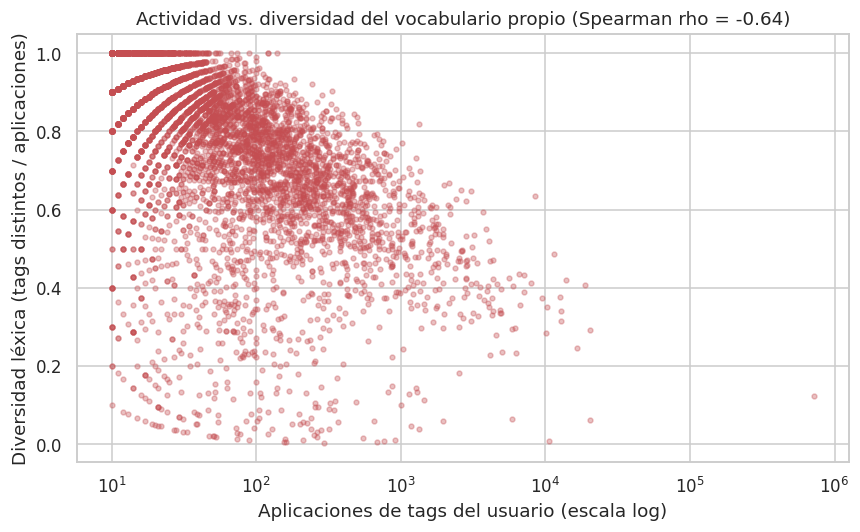

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(perfil_usuario["n_aplicaciones"], perfil_usuario["diversidad_lexica"],
           s=10, alpha=0.35, color="#C44E52")
ax.set_xscale("log")
ax.set_xlabel("Aplicaciones de tags del usuario (escala log)")
ax.set_ylabel("Diversidad léxica (tags distintos / aplicaciones)")
ax.set_title(f"Actividad vs. diversidad del vocabulario propio (Spearman rho = {rho:.2f})")
fig.tight_layout()
plt.show()

**Resultados:** **ρ = -0.641** (p < 0.001) — una asociación negativa, moderada a fuerte: a más
aplicaciones de tags pone un usuario, **menor** es la proporción de palabras distintas que usa. La
mediana de diversidad léxica es 0.82 (o sea, en promedio el 82 % de lo que etiqueta un usuario típico
son palabras que no ha repetido antes), pero cae marcadamente entre los usuarios más prolíficos.

**Conclusión:** los usuarios muy activos no están explorando vocabulario nuevo con cada aplicación —
tienden a reutilizar un conjunto relativamente estable de palabras favoritas ("atmospheric", "sci-fi",
"funny"...) sobre muchas películas distintas, en vez de generar descripciones únicas para cada una.
Es un patrón esperable de cómo funciona el etiquetado repetitivo a gran escala, y es consistente con lo
observado en la sección 8: el usuario 78213 (36 % de la actividad total) es, casi por definición, uno
de los casos con menor diversidad léxica relativa de toda la tabla.

### 9.2 Longitud del tag a través del tiempo

**Qué se calcula:** correlación de Spearman entre el año en que se puso un tag y su longitud en
caracteres, para ver si el estilo de etiquetado (más descriptivo/más telegráfico) ha cambiado con los
años de vida de la plataforma.

**Hipótesis:** H₀: ρ = 0.

In [21]:
rho_año, p_año = stats.spearmanr(tags_limpio["anio"], tags_limpio["n_caracteres"])
print(f"Spearman año ~ longitud del tag (caracteres): rho = {rho_año:.3f} | p = {p_año:.2e}")

longitud_por_año = tags_limpio.groupby("anio")["n_caracteres"].mean()
longitud_por_año.round(2)

Spearman año ~ longitud del tag (caracteres): rho = 0.076 | p = 0.00e+00


anio
2005     9.48
2006    11.02
2007    11.09
2008    11.91
2009    10.80
2010    10.94
2011    10.76
2012    10.76
2013    10.59
2014    11.30
2015    10.52
2016    10.60
2017    10.59
2018    10.11
2019    10.68
2020    10.55
2021    11.98
2022    11.85
2023    10.98
Name: n_caracteres, dtype: float64

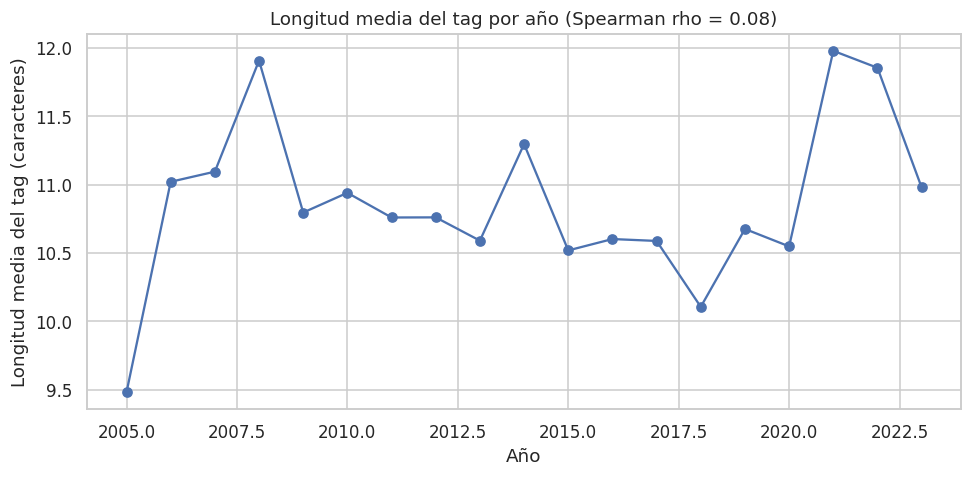

In [22]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(longitud_por_año.index, longitud_por_año.values, marker="o", color="#4C72B0")
ax.set_xlabel("Año")
ax.set_ylabel("Longitud media del tag (caracteres)")
ax.set_title(f"Longitud media del tag por año (Spearman rho = {rho_año:.2f})")
fig.tight_layout()
plt.show()

**Resultados:** **ρ = 0.076** (p < 0.001) — estadísticamente significativo solo por el enorme
tamaño de la muestra (casi 2 millones de observaciones), pero un efecto **despreciable** en la
práctica. La longitud media se mueve en una banda estrecha, entre 9.5 y 12.0 caracteres, sin una
tendencia clara de crecimiento o reducción a lo largo de casi dos décadas.

**Conclusión:** el estilo de etiquetado (largo típico de una etiqueta) se ha mantenido notablemente
estable desde 2005 hasta 2023 — no hay evidencia de que los usuarios se hayan vuelto más breves ni más
descriptivos con el tiempo.

### 9.3 Concentración de etiquetado por película

In [23]:
por_pelicula = tags_limpio.groupby("movieId").size().sort_values(ascending=False)
print(por_pelicula.describe().round(2))

n_top = int(round(len(por_pelicula) * 0.10))
top_peliculas = por_pelicula.head(n_top)
print(f"\nEl 10% de películas más etiquetadas ({n_top:,} películas) concentra el "
      f"{top_peliculas.sum() / por_pelicula.sum() * 100:.1f}% de todas las aplicaciones de tags")

count    51069.00
mean        39.02
std        161.12
min          1.00
25%          2.00
50%          5.00
75%         16.00
max       6697.00
dtype: float64

El 10% de películas más etiquetadas (5,107 películas) concentra el 78.0% de todas las aplicaciones de tags


**Resultados:** mediana de solo 5 aplicaciones de tags por película, frente a una media de 39 — el
10 % de las películas más etiquetadas concentra el 78.0 % de todas las aplicaciones.

**Conclusión:** el mismo patrón de concentración extrema que aparece en casi cualquier variable de
interacción de usuarios en este proyecto (popularidad de calificación, actividad de etiquetado por
usuario) se repite también del lado de las películas: unas pocas películas —presumiblemente las mismas
que dominan la popularidad en `ratings.csv`— acumulan la inmensa mayoría de la conversación textual de
la plataforma.

## 10. Resumen de hallazgos y limitaciones

### Hallazgos principales

1. **La tabla está limpia y bien referenciada:** solo 6 nulos residuales, cero duplicados, cero
   huérfanos contra `movies.csv`.
2. **Etiquetar es una actividad minoritaria:** solo 15 833 usuarios lo han hecho alguna vez (frente a
   los cientos de miles que calificaron), y cubren el 58.7 % del catálogo.
3. **Un solo usuario (`userId` 78213) explica el 36.2 % de toda la actividad de etiquetado**,
   concentrada en ráfagas puntuales en 2018 y 2021 — muy probablemente una importación masiva de datos,
   no un usuario humano etiquetando manualmente. Distorsiona fuertemente los estadísticos de actividad,
   pero apenas afecta el vocabulario más frecuente.
4. **El vocabulario de etiquetado sigue la ley de Zipf** (pendiente log-log de -1.27, R² = 0.97): un
   núcleo pequeño de palabras (mayormente géneros escritos en texto libre) domina el uso, con una cola
   larga de más de 67 000 palabras que aparecen una sola vez.
5. **A mayor actividad de un usuario, menor la diversidad relativa de su propio vocabulario**
   (ρ = -0.64): los usuarios más prolíficos repiten un set reducido de palabras favoritas sobre muchas
   películas, más que explorar vocabulario nuevo constantemente.
6. **El estilo de etiquetado (longitud del texto) se ha mantenido estable** durante casi 20 años de
   historia de la plataforma (ρ = 0.08, prácticamente nulo).
7. **Existen problemas menores de codificación de caracteres** (mojibake, 0.026 % de las filas) y una
   cola de "tags" que en realidad son mini-reseñas de hasta 241 caracteres.

### Limitaciones

* **La heurística de "nombre propio" (sección 7.6) es simple y aproximada:** captura genuinos nombres
  de actores/directores, pero también frases que casualmente van en mayúscula por palabra sin ser
  nombres de persona ("World War II", "New York City"). No se usó una herramienta de reconocimiento de
  entidades porque está fuera del alcance de un notebook exploratorio de una sola tabla.
* **El origen del usuario 78213 es una hipótesis, no un hecho verificado:** esta tabla no tiene
  ninguna columna que confirme si se trata de un bot, una importación masiva o un caso legítimo de
  uso intensivo; solo se puede inferir del patrón de los datos.
* **La normalización de texto (sección 6) solo corrige mayúsculas y espacios**, no errores
  ortográficos ni sinónimos ("sci-fi" vs. "scifi" vs. "science fiction" siguen contando como tags
  distintos), así que la diversidad léxica real es, en realidad, algo menor a la reportada.
* **No se cruza con `movies.csv` más allá de la validación referencial de la sección 5**, ni con
  `ratings.csv`: cualquier pregunta sobre si el etiquetado se relaciona con el género o con la
  calificación de una película corresponde a los notebooks `movies_tags.ipynb` y `ratings_tags.ipynb`
  del equipo.